In [1]:
import geopandas
import libpysal
import esda
import spreg
import matplotlib

In [2]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv('baeume.csv')

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs = "EPSG:4326"
)
gdf = gdf.to_crs(epsg=3857)
gdf.head()

,latitude,longitude,uuid,gattung_botanisch,gattung_deutsch,art_botanisch,art_deutsch,alleebaum,hoehe,stammdurchmesser,stammumfang,kronendurchmesser,baumpatenschaft,geometry
0,54.057654,12.100881,d04f4edf-c22b-481d-8140-f5da1203b9c7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1347063.919 7181082.929)
1,54.053463,12.098658,9ac13cb1-d6fa-42ae-9374-0300965a97d7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1346816.406 7180288.122)
2,54.068021,12.123567,253aad1a-c704-40fb-8401-7d88f94559d2,Quercus,Eiche,Quercus robur,Stiel-Eiche,0,18.0,35.00,109.96,12.0,0,POINT (1349589.314 7183049.253)
3,54.068164,12.113794,d7a4e358-8634-4497-988e-d2e51487d1cb,Acer,Ahorn,Acer saccharum,Zucker-Ahorn,0,20.0,50.93,160.00,9.2,0,POINT (1348501.391 7183076.331)
4,54.066913,12.117171,aa50bcd3-125c-43d5-9859-9afa368c73e0,Quercus,Eiche,Quercus rubra,Amerikanische Roteiche,1,9.0,31.83,100.00,10.0,0,POINT (1348877.355 7182838.966)


In [3]:
gdf.isna().sum()
gdf.describe()

,latitude,longitude,alleebaum,hoehe,stammdurchmesser,stammumfang,kronendurchmesser,baumpatenschaft
count,70901.000000,70901.000000,70901.000000,69486.000000,69378.000000,69378.000000,69393.000000,70901.000000
mean,54.113202,12.106738,0.174469,12.407147,32.804386,103.058039,6.422328,0.002172
std,0.036345,0.044526,0.379515,8.370137,26.152694,82.161219,3.770057,0.046555
min,54.004862,12.006991,0.000000,0.400000,0.050000,0.160000,0.100000,0.000000
25%,54.082481,12.071525,0.000000,7.000000,17.000000,53.410000,4.000000,0.000000
50%,54.104562,12.096546,0.000000,11.000000,28.010000,88.000000,6.000000,0.000000
75%,54.139616,12.139764,0.000000,16.000000,43.000000,135.090000,8.100000,0.000000
max,54.252528,12.347259,1.000000,915.000000,2588.000000,8130.440000,164.000000,1.000000


In [4]:
df.rename(columns={
    "gattung_botanisch": "genus_botanical",
    "gattung_deutsch": "genus_german",
    "art_botanisch": "species_botanical",
    "art_deutsch": "species_german",
    "alleebaum": "avenue_tree",
    "hoehe": "height",
    "stammdurchmesser": "trunk_diameter",
    "stammumfang": "trunk_circumference",
    "kronendurchmesser": "crown_diameter",
    "baumpatenschaft": "tree_sponsorship"
}, inplace=True)

In [5]:
gdf = gdf.rename(columns={"gattung_botanisch": "genus_botanical",
    "gattung_deutsch": "genus_german",
    "art_botanisch": "species_botanical",
    "art_deutsch": "species_german",
    "alleebaum": "avenue_tree",
    "hoehe": "height",
    "stammdurchmesser": "trunk_diameter",
    "stammumfang": "trunk_circumference",
    "kronendurchmesser": "crown_diameter",
    "baumpatenschaft": "tree_sponsorship" })

In [6]:
df.columns

Index(['latitude', 'longitude', 'uuid', 'genus_botanical', 'genus_german',
       'species_botanical', 'species_german', 'avenue_tree', 'height',
       'trunk_diameter', 'trunk_circumference', 'crown_diameter',
       'tree_sponsorship'],
      dtype='object')

In [7]:
gdf['height'].describe()

,height
count,69486.000000
mean,12.407147
std,8.370137
min,0.400000
25%,7.000000
50%,11.000000
75%,16.000000
max,915.000000


In [8]:
gdf['height'].isna().sum()

np.int64(1415)

In [9]:
gdf = gdf[(gdf['height'] > 0) & (gdf['height'] <= 50)]

In [10]:
gdf['trunk_diameter'].describe()

,trunk_diameter
count,69122.00000
mean,32.80874
std,26.13320
min,0.05000
25%,17.00000
50%,28.01000
75%,43.00000
max,2588.00000


In [11]:
gdf[['trunk_diameter','trunk_circumference']].describe()

,trunk_diameter,trunk_circumference
count,69122.00000,69122.000000
mean,32.80874,103.071722
std,26.13320,82.099978
min,0.05000,0.160000
25%,17.00000,53.410000
50%,28.01000,88.000000
75%,43.00000,135.090000
max,2588.00000,8130.440000


In [12]:
Q1 = gdf['trunk_diameter'].quantile(0.25)
Q3 = gdf['trunk_diameter'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

gdf = gdf[(gdf['trunk_diameter'] >= lower) &
          (gdf['trunk_diameter'] <= upper)]

In [13]:
gdf = gdf.drop_duplicates(subset='uuid')

In [14]:
gdf.isnull().sum()

,0
latitude,0
longitude,0
uuid,0
genus_botanical,0
genus_german,0
species_botanical,0
species_german,0
avenue_tree,0
height,0
trunk_diameter,0


In [15]:
gdf = gdf.dropna(subset=['height', 'trunk_diameter', 'crown_diameter'])

In [16]:
gdf.shape
gdf.isnull().sum()
gdf.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

here we got to know that the coordinates are projected, distances are in meters, spatial weights will work corr

Spatial AutoCorrelation


Since this is a point dataset KNN is best

In [17]:
from libpysal.weights import KNN

w = KNN.from_dataframe(gdf, k=8)
w.transform = 'r'

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 174 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


we are initially choosing 8 because it is a standard in urban spatial analysi

In [18]:
w.n_components

174

In [19]:
w.component_labels[:20]

array([0, 0, 0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1],
      dtype=int32)

In [20]:
import pandas as pd

component_sizes = pd.Series(w.component_labels).value_counts()

component_sizes.head(10)

,count
0,34842
1,16367
36,1876
44,1336
5,840
30,735
41,633
67,605
42,426
9,407


In [21]:
component_sizes.describe()

,count
count,174.000000
mean,384.850575
std,2910.032914
min,9.000000
25%,16.000000
50%,31.000000
75%,57.750000
max,34842.000000


Getting the Moron's I and P value for the height

In [22]:
from esda.moran import Moran

y = gdf['height']
mi = Moran(y, w)

print("Moran’s I:", mi.I)
print("p-value:", mi.p_sim)

Moran’s I: 0.6692395595045978
p-value: 0.001


In [23]:
# =========================================
# GETIS-ORD Gi* Z-SCORE (HOTSPOT ANALYSIS)
# =========================================

from esda.getisord import G_Local
import numpy as np

# Select variable (CHANGE NAME)
variable = "height"

y = gdf[variable].values

# Compute Gi*
gi = G_Local(y, w)

# Store results
gdf["GiZScore"] = gi.Zs
gdf["GiPValue"] = gi.p_sim

print("Gi* calculation completed")


Gi* calculation completed


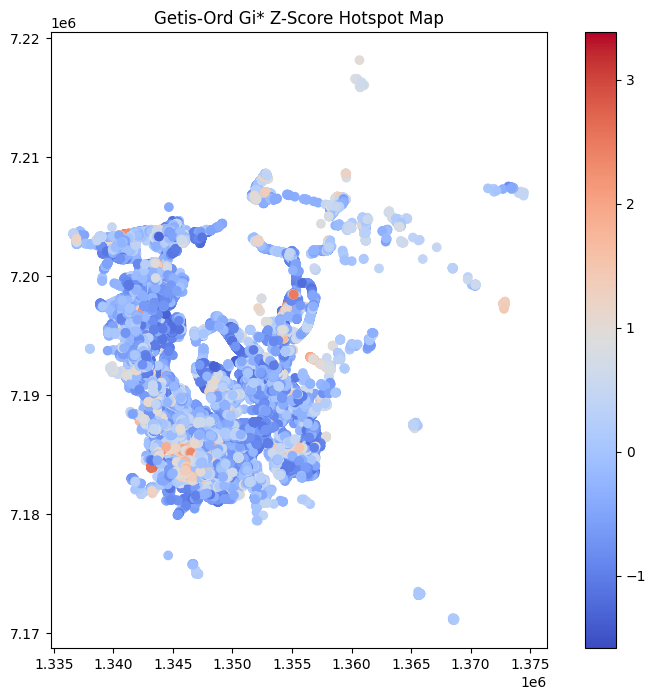

In [24]:
# =========================================
# PLOT Z-SCORE HOTSPOT MAP
# =========================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf.plot(
    column="GiZScore",
    cmap="coolwarm",
    legend=True,
    ax=ax
)

plt.title("Getis-Ord Gi* Z-Score Hotspot Map")
plt.show()


Finding the Local Moron's I(LISA)

In [25]:
from esda.moran import Moran_Local

lisa = Moran_Local(y, w)

gdf['lisa_cluster'] = lisa.q
gdf['lisa_p'] = lisa.p_sim

In [26]:
gdf['significant'] = gdf['lisa_p'] < 0.05

<Axes: >

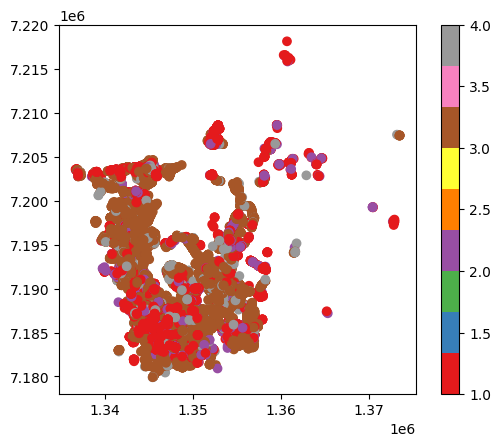

In [27]:
gdf[gdf['significant']].plot(column='lisa_cluster', cmap='Set1', legend=True)

In [28]:
sig = gdf[gdf['significant'] == True]

In [29]:
sig['lisa_cluster'].value_counts()

,count
lisa_cluster,
3,19548
1,12444
2,1734
4,740


This result says that there are 19304 low-low, 12170 high-high, 1653 low-high, 729 high-low

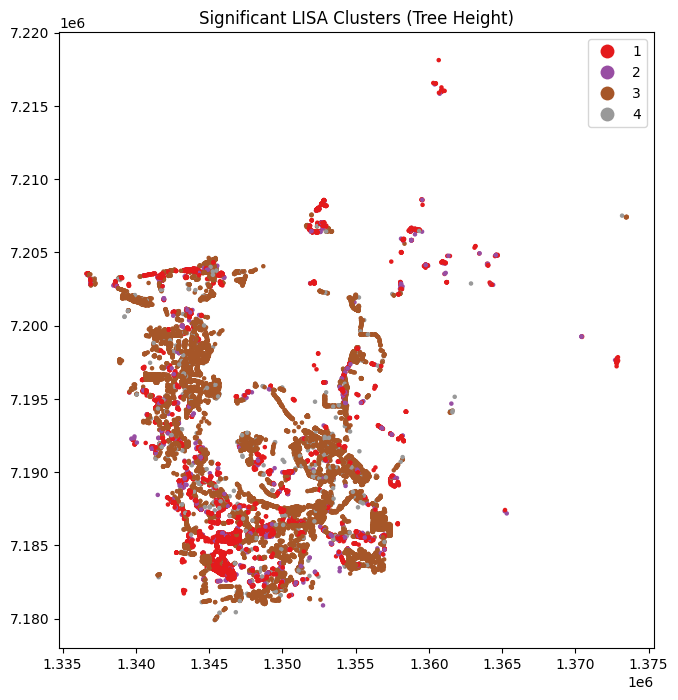

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(8,8))

sig.plot(column='lisa_cluster',
         categorical=True,
         cmap='Set1',
         legend=True,
         markersize=5,
         ax=ax)

ax.set_title("Significant LISA Clusters (Tree Height)")
plt.show()

In [31]:
from spreg import OLS
import numpy as np

y = gdf['height'].values.reshape(-1,1)

X = gdf[['trunk_diameter','crown_diameter']].values

model = OLS(y, X)

print(model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :     dep_var                Number of Observations:       66964
Mean dependent var  :     12.1161                Number of Variables   :           3
S.D. dependent var  :      6.5405                Degrees of Freedom    :       66961
R-squared           :      0.5530
Adjusted R-squared  :      0.5530
Sum squared residual: 1.28055e+06                F-statistic           :  41415.4245
Sigma-square        :      19.124                Prob(F-statistic)     :           0
S.E. of regression  :       4.373                Log likelihood        : -193819.484
Sigma-square ML     :      19.123                Akaike info criterion :  387644.968
S.E of regression ML:      4.3730                Schwarz criterion     :  387672.304

------------------------------------------------------------


this data indicates that trees with thicker trunks and wider crowns are taller

we got Breusch-Pagan test and Koenker-Bassett test p values as 0 this indicates Heteroskedasticity exists Variance of errors is NOT constant

this suggests that Model errors vary across space Spatial heterogeneity likely present

If this residual show spatial autocorrelation OLS is insufficient, we need spatial models

In [32]:
from esda.moran import Moran

residuals = model.u   # residuals from OLS

mi_res = Moran(residuals, w)

print("Residual Moran’s I:", mi_res.I)
print("p-value:", mi_res.p_sim)

Residual Moran’s I: 0.5640160137544747
p-value: 0.001


In [33]:
# from spreg import ML_Lag

# slm = ML_Lag(y, X, w=w, method = 'LU')

# print(slm.summary)

In [34]:
# from spreg import ML_Lag

# slm = ML_Lag(y, X, w=w, method='ORD')
# print(slm.summary)


In [35]:
from spreg import GM_Lag

slm_gmm = GM_Lag(y, X, w=w)
print(slm_gmm.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       66964
Mean dependent var  :     12.1161                Number of Variables   :           4
S.D. dependent var  :      6.5405                Degrees of Freedom    :       66960
Pseudo R-squared    :      0.7302
Spatial Pseudo R-squared:  0.5852

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.79178         0.03973        19.92757         0.00000
               var_1         0.16443         0.00129       127.81617         0.00000
               var_2         0.28748      

In [36]:
gdf_sample = gdf.sample(n=20000, random_state=42)

In [37]:
from libpysal.weights import KNN

w_s = KNN.from_dataframe(gdf_sample, k=8)
w_s.transform = 'r'

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 33 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [38]:
import numpy as np

y_s = gdf_sample['height'].values.reshape(-1,1)
X_s = gdf_sample[['trunk_diameter','crown_diameter']].values

In [39]:
# from spreg import ML_Lag

# slm = ML_Lag(y_s, X_s, w=w_s, method='LU')

# print(slm.summary)

In [40]:
from spreg import GM_Lag

slm = GM_Lag(y_s, X_s, w=w_s)

print(slm.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       20000
Mean dependent var  :     12.1393                Number of Variables   :           4
S.D. dependent var  :      6.5614                Degrees of Freedom    :       19996
Pseudo R-squared    :      0.7043
Spatial Pseudo R-squared:  0.5936

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.50998         0.07862         6.48698         0.00000
               var_1         0.17515         0.00234        74.94594         0.00000
               var_2         0.28784      

In [41]:
# from spreg import ML_Error

# sem = ML_Error(y_s, X_s, w=w_s, method='LU')
# print(sem.summary)

In [42]:
from spreg import GM_Error

sem = GM_Error(y_s, X_s, w=w_s)
print(sem.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES
------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       20000
Mean dependent var  :     12.1393                Number of Variables   :           3
S.D. dependent var  :      6.5614                Degrees of Freedom    :       19997
Pseudo R-squared    :      0.5577

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         4.73547         0.09205        51.44536         0.00000
               var_1         0.17696         0.00223        79.43775         0.00000
               var_2         0.27993         0.01016        27.54766

In [43]:
from sklearn.model_selection import train_test_split
import numpy as np

X_full = gdf[['trunk_diameter','crown_diameter']].values
y_full = gdf['height'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

In [44]:
from spreg import OLS

ols_train = OLS(y_train, X_train)

print(ols_train.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :     dep_var                Number of Observations:       53571
Mean dependent var  :     12.1129                Number of Variables   :           3
S.D. dependent var  :      6.5356                Degrees of Freedom    :       53568
R-squared           :      0.5505
Adjusted R-squared  :      0.5505
Sum squared residual: 1.02858e+06                F-statistic           :  32799.5863
Sigma-square        :      19.201                Prob(F-statistic)     :           0
S.E. of regression  :       4.382                Log likelihood        : -155163.258
Sigma-square ML     :      19.200                Akaike info criterion :  310332.516
S.E of regression ML:      4.3818                Schwarz criterion     :  310359.182

------------------------------------------------------------

In [45]:
beta = ols_train.betas

# Add constant manually
X_test_const = np.hstack((np.ones((X_test.shape[0],1)), X_test))

y_pred = X_test_const @ beta

In [46]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Test RMSE: 4.337619543302078


In [47]:
gdf_sample = gdf.sample(n=20000, random_state=42).copy()

In [48]:
from sklearn.model_selection import train_test_split

gdf_train, gdf_test = train_test_split(
    gdf_sample, test_size=0.2, random_state=42
)

In [49]:
from libpysal.weights import KNN

w_train = KNN.from_dataframe(gdf_train, k=8)
w_train.transform = 'r'

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 25 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [50]:
import numpy as np

X_train = gdf_train[['trunk_diameter','crown_diameter']].values
y_train = gdf_train['height'].values.reshape(-1,1)

X_test = gdf_test[['trunk_diameter','crown_diameter']].values
y_test = gdf_test['height'].values.reshape(-1,1)

In [51]:
# from spreg import ML_Lag

# slm_train = ML_Lag(y_train, X_train, w=w_train, method='LU')

# print(slm_train.summary)

In [52]:
from spreg import GM_Lag

slm_train = GM_Lag(y_train, X_train, w=w_train)

print(slm_train.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       16000
Mean dependent var  :     12.1294                Number of Variables   :           4
S.D. dependent var  :      6.5746                Degrees of Freedom    :       15996
Pseudo R-squared    :      0.7001
Spatial Pseudo R-squared:  0.5971

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.39498         0.08837         4.46974         0.00001
               var_1         0.17694         0.00258        68.62136         0.00000
               var_2         0.28285      

In [53]:
rho = slm_train.rho
beta = slm_train.betas

In [54]:
import numpy as np

X_test_const = np.hstack((np.ones((X_test.shape[0],1)), X_test))

In [55]:
print("X_test_const shape:", X_test_const.shape)
print("beta shape:", beta.shape)

X_test_const shape: (4000, 3)
beta shape: (4, 1)


In [56]:
# Remove rho from beta
beta_x = beta[:-1]   # keeps first 3 rows only

print("beta_x shape:", beta_x.shape)

# Matrix multiplication
XB = X_test_const @ beta_x

# Apply spatial multiplier
y_pred_slm = XB / (1 - rho)

beta_x shape: (3, 1)


In [57]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_slm = np.sqrt(mean_squared_error(y_test, y_pred_slm))
print("SLM Test RMSE:", rmse_slm)

SLM Test RMSE: 4.561110838056934


In [58]:
from spreg import OLS

ols_train = OLS(y_train, X_train)
beta_ols = ols_train.betas

X_test_const = np.hstack((np.ones((X_test.shape[0],1)), X_test))
y_pred_ols = X_test_const @ beta_ols

rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
print("OLS Test RMSE:", rmse_ols)

OLS Test RMSE: 4.340014374795412


In [59]:
from esda.moran import Moran

# residuals from SEM (on sample model)
residuals_sem = sem.u

mi_sem = Moran(residuals_sem, w_s)

print("SEM Residual Moran’s I:", mi_sem.I)
print("p-value:", mi_sem.p_sim)

SEM Residual Moran’s I: 0.5283840107773446
p-value: 0.001


In [60]:
!pip install mgwr

In [61]:
gdf_gwr = gdf.sample(n=10000, random_state=42).copy()

In [62]:
coords = np.column_stack((gdf_gwr.geometry.x, gdf_gwr.geometry.y))

X_gwr = gdf_gwr[['trunk_diameter','crown_diameter']].values
y_gwr = gdf_gwr['height'].values.reshape(-1,1)

In [63]:
# from mgwr.sel_bw import Sel_BW

# selector = Sel_BW(coords, y_gwr, X_gwr)
# bw = selector.search()

# print("Optimal bandwidth:", bw)

In [64]:
import multiprocessing as mp
from mgwr.sel_bw import Sel_BW

# 1. Check how many cores you have (optional)
cores = mp.cpu_count()
print(f"Using {cores} cores for optimization...")

# 2. Create the pool
# 'with' ensures the pool is closed properly after finishing
with mp.Pool(processes=cores) as pool:

    # 3. Initialize the selector
    # Note: multi_bw is for Multiscale GWR.
    # For standard GWR bandwidth search, we just pass the pool to .search()
    selector = Sel_BW(coords, y_gwr, X_gwr)

    # 4. Run the search using the pool
    bw = selector.search(pool=pool)

print("Optimal bandwidth found:", bw)

Using 2 cores for optimization...


/tmp/ipython-input-1582203340.py:18: RuntimeWarning: The pool parameter is no longer used and will have no effect; parallelization is default and implemented using joblib instead.
  bw = selector.search(pool=pool)


Optimal bandwidth found: 49.0


In [65]:
from mgwr.gwr import GWR

gwr_model = GWR(coords, y_gwr, X_gwr, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())

Model type                                                         Gaussian
Number of observations:                                               10000
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                         189554.374
Log-likelihood:                                                  -28899.839
AIC:                                                              57805.679
AICc:                                                             57807.683
BIC:                                                              97478.602
R2:                                                                   0.565
Adj. R2:                                                              0.565

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [66]:
from esda.moran import Moran
from libpysal.weights import KNN

coords = np.column_stack((gdf_gwr.geometry.x, gdf_gwr.geometry.y))
w_gwr = KNN.from_array(coords, k=8)
w_gwr.transform = 'r'

residuals_gwr = gwr_results.resid_response

mi_gwr = Moran(residuals_gwr, w_gwr)

print("GWR Residual Moran’s I:", mi_gwr.I)
print("p-value:", mi_gwr.p_sim)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


GWR Residual Moran’s I: 0.007739417498736345
p-value: 0.05


In [67]:
X_full = gdf[['trunk_diameter','crown_diameter','avenue_tree']].values
y_full = gdf['height'].values.reshape(-1,1)

ols_full = OLS(y_full, X_full)
print(ols_full.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :     dep_var                Number of Observations:       66964
Mean dependent var  :     12.1161                Number of Variables   :           4
S.D. dependent var  :      6.5405                Degrees of Freedom    :       66960
R-squared           :      0.5691
Adjusted R-squared  :      0.5690
Sum squared residual: 1.23448e+06                F-statistic           :  29473.1123
Sigma-square        :      18.436                Prob(F-statistic)     :           0
S.E. of regression  :       4.294                Log likelihood        : -192592.779
Sigma-square ML     :      18.435                Akaike info criterion :  385193.559
S.E of regression ML:      4.2936                Schwarz criterion     :  385230.007

------------------------------------------------------------

In [68]:
residuals = ols_full.u

mi_new = Moran(residuals, w)
print("New OLS Residual Moran’s I:", mi_new.I)
print("p-value:", mi_new.p_sim)

New OLS Residual Moran’s I: 0.5440043930709886
p-value: 0.001


In [69]:
# gdf_sample = gdf.sample(n=20000, random_state=42).copy()

# X_s = gdf_sample[['trunk_diameter','crown_diameter','avenue_tree']].values
# y_s = gdf_sample['height'].values.reshape(-1,1)

# w_s = KNN.from_dataframe(gdf_sample, k=8)
# w_s.transform = 'r'

# slm = ML_Lag(y_s, X_s, w=w_s, method='LU')
# print(slm.summary)

In [70]:
from spreg import GM_Lag
from libpysal.weights import KNN

# 1. Increase K slightly to reduce disconnected components (8 -> 12)
# This helps 'bridge' those 33 disconnected islands.
w_s = KNN.from_dataframe(gdf_sample, k=12)
w_s.transform = 'r'

# 2. Use GM_Lag instead of ML_Lag
# This is nearly instantaneous even for 20,000+ rows
slm_fast = GM_Lag(y_s, X_s, w=w_s, w_lags=1)

print(slm_fast.summary)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       20000
Mean dependent var  :     12.1393                Number of Variables   :           4
S.D. dependent var  :      6.5614                Degrees of Freedom    :       19996
Pseudo R-squared    :      0.7047
Spatial Pseudo R-squared:  0.5991

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.20281         0.07993         2.53726         0.01117
               var_1         0.17422         0.00231        75.28190         0.00000
               var_2         0.28815      

Local Spatial autocorrelation




<Figure size 800x600 with 0 Axes>

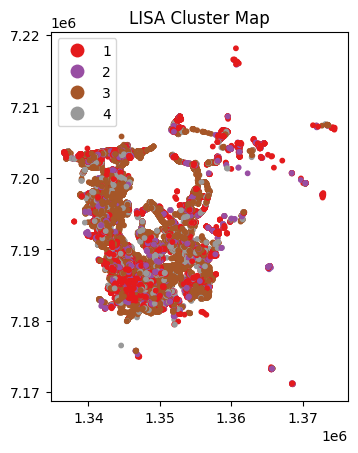

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
gdf.assign(
    cluster=lisa.q
).plot(
    column="cluster",
    categorical=True,
    legend=True,
    cmap="Set1",
    markersize=10
)

plt.title("LISA Cluster Map")
plt.show()


Spatial Heterogeniety

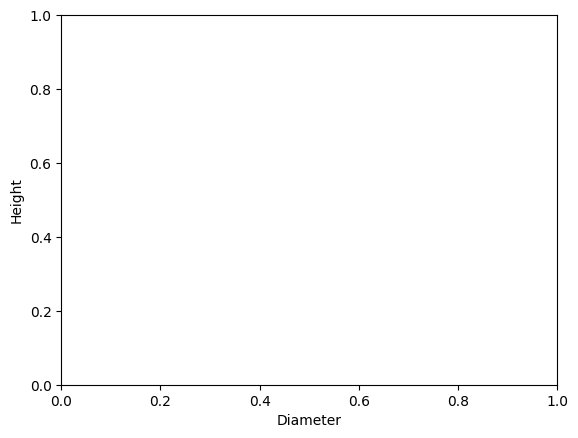

In [72]:
plt.xlabel("Diameter")
plt.ylabel("Height")
plt.show()

Spatial Stationarity

In [73]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import numpy as np

coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

y = gdf["height"].values.reshape((-1,1))
X = gdf[["diameter"]].values

bw = Sel_BW(coords, y, X).search()

gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())

KeyError: "None of [Index(['diameter'], dtype='object')] are in the [columns]"